In [2]:
import re
import numpy as np
import pandas as pd
import itertools
from tqdm.auto import tqdm

import matplotlib.pyplot as plt


from bert_score import score
import pymorphy3
from rapidfuzz.distance import Levenshtein
from sacrebleu.metrics import BLEU, CHRF


import warnings
import logging
from transformers import logging as hf_logging

warnings.filterwarnings("ignore")

hf_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("bert_score").setLevel(logging.ERROR)

In [3]:
files = {
    0.0: "c2_from_b2_augmented_llama3_temp_0_0.csv",
    0.1: "c2_from_b2_augmented_llama3_temp_0_1.csv",
    0.2: "c2_from_b2_augmented_llama3_temp_0_2.csv",
    0.3: "c2_from_b2_augmented_llama3_temp_0_3.csv",
    0.4: "c2_from_b2_augmented_llama3_temp_0_4.csv",
    0.5: "c2_from_b2_augmented_llama3_temp_0_5.csv",
    0.6: "c2_from_b2_augmented_llama3_temp_0_6.csv",
    0.7: "c2_from_b2_augmented_llama3_temp_0_7.csv",
    0.8: "c2_from_b2_augmented_llama3_temp_0_8.csv",
    0.9: "c2_from_b2_augmented_llama3_temp_0_9.csv",
    1.0: "c2_from_b2_augmented_llama3_temp_1_0.csv",
    1.1: "c2_from_b2_augmented_llama3_temp_1_1.csv",
    1.2: "c2_from_b2_augmented_llama3_temp_1_2.csv",
    1.3: "c2_from_b2_augmented_llama3_temp_1_3.csv",
    1.4: "c2_from_b2_augmented_llama3_temp_1_4.csv",
    1.5: "c2_from_b2_augmented_llama3_temp_1_5.csv",
}

# Вспомогательные функции подсчета метрик

In [4]:
morph = pymorphy3.MorphAnalyzer()

def tokenize_words(text):
    text = str(text).lower()
    return re.findall(r"[а-яёa-z]+", text)


def lemmatize_text(text):
    words = tokenize_words(text)
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [5]:
def bertscore_pair(original_text, augmented_text, model_type="DeepPavlov/rubert-base-cased"):
    P, R, F1 = score(
        [augmented_text],      
        [original_text],       
        model_type=model_type,
        num_layers=12,
        lang="ru",
        verbose=False
    )

    return {
        "precision": P.item(),
        "recall": R.item(),
        "f1": F1.item()
    }

In [6]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF()


def jaccard_similarity_lemmas(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas and not aug_lemmas:
        return 1.0

    if not orig_lemmas or not aug_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas | aug_lemmas)


def common_words_ratio(original, augmented):
    orig_lemmas = set(lemmatize_text(original))
    aug_lemmas = set(lemmatize_text(augmented))

    if not orig_lemmas:
        return 0.0

    return len(orig_lemmas & aug_lemmas) / len(orig_lemmas)


def normalized_levenshtein_distance(original, augmented):
    original = str(original)
    augmented = str(augmented)

    max_len = max(len(original), len(augmented))

    if max_len == 0:
        return 0.0

    distance = Levenshtein.distance(original, augmented)
    return distance / max_len


def normalized_levenshtein_similarity(original, augmented):
    return 1 - normalized_levenshtein_distance(original, augmented)

In [7]:
def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])

    return dp[m][n]


def rouge_l_f1(original, augmented):
    orig_tokens = tokenize_words(original)
    aug_tokens = tokenize_words(augmented)

    if not orig_tokens or not aug_tokens:
        return 0.0

    lcs = lcs_length(orig_tokens, aug_tokens)

    precision = lcs / len(aug_tokens)
    recall = lcs / len(orig_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [8]:
def bleu_score(original, augmented):
    score = bleu_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100


def chrf_score(original, augmented):
    score = chrf_metric.sentence_score(
        hypothesis=str(augmented),
        references=[str(original)]
    ).score

    return score / 100

# Сравнение исходных и аугментированных текстов внутри одной температуры

In [9]:
def calculate_pair_metrics(original, augmented):
    return {
        "bert_score": bertscore_pair(original, augmented),
        "jaccard_lemmas": jaccard_similarity_lemmas(original, augmented),
        "common_words_ratio": common_words_ratio(original, augmented),
        "levenshtein_distance": normalized_levenshtein_distance(original, augmented),
        "levenshtein_similarity": normalized_levenshtein_similarity(original, augmented),
        "rouge_l": rouge_l_f1(original, augmented),
        "bleu": bleu_score(original, augmented),
        "chrf": chrf_score(original, augmented),
    }

In [10]:
all_rows = []

for temp, path in files.items():
    df = pd.read_csv(path)

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Обработка строк"):
        original = row['text']
        augmented = row['augmented-text']

        metrics = calculate_pair_metrics(original, augmented)

        metrics["temperature"] = temp
        metrics["original"] = original
        metrics["augmented"] = augmented

        all_rows.append(metrics)

pair_metrics_df = pd.DataFrame(all_rows)

pair_metrics_df

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

...

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

Обработка строк:   0%|          | 0/120 [00:00<?, ?it/s]

,bert_score,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,temperature,original,augmented
0,"{'precision': 0.7569849491119385, 'recall': 0....",0.300000,0.500000,0.520619,0.479381,0.482759,0.230120,0.448040,0.0,По дороге к её дому его ожидали разные препятс...,На пути к ее дому его ожидали различные барьер...
1,"{'precision': 0.5391607284545898, 'recall': 0....",0.230769,0.450000,0.662791,0.337209,0.156863,0.027795,0.398800,0.0,Что же выявил наш анализ? Самое главное — длит...,Анализ нашего исследования привел к следующим ...
2,"{'precision': 0.7030469179153442, 'recall': 0....",0.375000,0.705882,0.568548,0.431452,0.425532,0.213192,0.615839,0.0,В начале конференции немецкий социолог сделал ...,На начальном этапе конференции немецкий социол...
3,"{'precision': 0.4995283782482147, 'recall': 0....",0.468085,0.785714,0.568389,0.431611,0.426667,0.132624,0.522582,0.0,Исследования этой пещеры начались ещё в XIX ве...,"Исследования пещеры начались еще в XIX веке, к..."
4,"{'precision': 0.5713186860084534, 'recall': 0....",0.354167,0.708333,0.633333,0.366667,0.371429,0.143991,0.526639,0.0,Жизнь славян была тесно связана с сельским хоз...,Славянская культура была тесно связана с аграр...
...,...,...,...,...,...,...,...,...,...,...,...
1915,"{'precision': 0.4712808430194855, 'recall': 0....",0.200000,0.562500,0.758824,0.241176,0.235294,0.107468,0.400063,1.5,Франц Лефорт родился в 1656 году в Женеве в се...,Родившийся в Женеве в 1656 году Франц Лефорт п...
1916,"{'precision': 0.6130070686340332, 'recall': 0....",0.425532,0.740741,0.491667,0.508333,0.555556,0.330103,0.662969,1.5,Своё современное название проспект получил в 1...,Продолжающая линия проспекта была названа в 17...
1917,"{'precision': 0.40242063999176025, 'recall': 0...",0.109091,0.375000,0.790640,0.209360,0.121212,0.018432,0.291348,1.5,Постоянно вижу припаркованные на тротуарах маш...,На протяжении времени мониторинг общественной ...
1918,"{'precision': 0.4141257107257843, 'recall': 0....",0.272727,0.666667,0.745257,0.254743,0.202899,0.074016,0.415248,1.5,По площади она в два раза больше Соединённых Ш...,Расположенная между материков держава с населе...


In [11]:
pair_metrics_df['bert_score_precision'] = [pair_metrics_df['bert_score'][i]['precision'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_recall'] = [pair_metrics_df['bert_score'][i]['recall'] for i in range(len(pair_metrics_df))]
pair_metrics_df['bert_score_f1'] = [pair_metrics_df['bert_score'][i]['f1'] for i in range(len(pair_metrics_df))]

del pair_metrics_df['bert_score']

pair_metrics_df

,jaccard_lemmas,common_words_ratio,levenshtein_distance,levenshtein_similarity,rouge_l,bleu,chrf,temperature,original,augmented,bert_score_precision,bert_score_recall,bert_score_f1
0,0.300000,0.500000,0.520619,0.479381,0.482759,0.230120,0.448040,0.0,По дороге к её дому его ожидали разные препятс...,На пути к ее дому его ожидали различные барьер...,0.756985,0.802089,0.778885
1,0.230769,0.450000,0.662791,0.337209,0.156863,0.027795,0.398800,0.0,Что же выявил наш анализ? Самое главное — длит...,Анализ нашего исследования привел к следующим ...,0.539161,0.576846,0.557367
2,0.375000,0.705882,0.568548,0.431452,0.425532,0.213192,0.615839,0.0,В начале конференции немецкий социолог сделал ...,На начальном этапе конференции немецкий социол...,0.703047,0.801941,0.749245
3,0.468085,0.785714,0.568389,0.431611,0.426667,0.132624,0.522582,0.0,Исследования этой пещеры начались ещё в XIX ве...,"Исследования пещеры начались еще в XIX веке, к...",0.499528,0.562364,0.529087
4,0.354167,0.708333,0.633333,0.366667,0.371429,0.143991,0.526639,0.0,Жизнь славян была тесно связана с сельским хоз...,Славянская культура была тесно связана с аграр...,0.571319,0.660932,0.612867
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,0.200000,0.562500,0.758824,0.241176,0.235294,0.107468,0.400063,1.5,Франц Лефорт родился в 1656 году в Женеве в се...,Родившийся в Женеве в 1656 году Франц Лефорт п...,0.471281,0.611824,0.532434
1916,0.425532,0.740741,0.491667,0.508333,0.555556,0.330103,0.662969,1.5,Своё современное название проспект получил в 1...,Продолжающая линия проспекта была названа в 17...,0.613007,0.733305,0.667782
1917,0.109091,0.375000,0.790640,0.209360,0.121212,0.018432,0.291348,1.5,Постоянно вижу припаркованные на тротуарах маш...,На протяжении времени мониторинг общественной ...,0.402421,0.524145,0.455287
1918,0.272727,0.666667,0.745257,0.254743,0.202899,0.074016,0.415248,1.5,По площади она в два раза больше Соединённых Ш...,Расположенная между материков держава с населе...,0.414126,0.525676,0.463281


In [12]:
metric_columns = [
    "bert_score_precision",
    "bert_score_recall",
    "bert_score_f1",
    "jaccard_lemmas",
    "common_words_ratio",
    "levenshtein_distance",
    "levenshtein_similarity",
    "rouge_l",
    "bleu",
    "chrf",
]

results_df = (
    pair_metrics_df
    .groupby("temperature")[metric_columns]
    .agg(["mean", "std", "min", "max"])
)

In [13]:
results_df_flat = results_df.copy()

results_df_flat.columns = [
    f"{metric}_{stat}"
    for metric, stat in results_df_flat.columns
]

results_df_flat = results_df_flat.reset_index()

In [14]:
results_df['bert_score_precision']

,mean,std,min,max
temperature,,,,
0.0,0.574426,0.091898,0.361573,0.808791
0.1,0.573362,0.086458,0.396784,0.797210
0.2,0.575087,0.084543,0.394373,0.808791
0.3,0.573265,0.096487,0.333959,0.834311
0.4,0.566765,0.085181,0.341037,0.795998
0.5,0.563434,0.088780,0.359806,0.832597
0.6,0.569561,0.095124,0.356264,0.791271
0.7,0.550912,0.094793,0.327625,0.785568
0.8,0.544722,0.095271,0.279034,0.861535


In [15]:
results_df['bert_score_recall']

,mean,std,min,max
temperature,,,,
0.0,0.665006,0.109048,0.391410,0.937085
0.1,0.665174,0.102364,0.414930,0.937085
0.2,0.671514,0.100467,0.417625,0.941570
0.3,0.660304,0.112937,0.347488,0.913489
0.4,0.656263,0.100073,0.406133,0.906070
0.5,0.652835,0.102804,0.397899,0.924163
0.6,0.656883,0.103526,0.403775,0.896355
0.7,0.642913,0.109993,0.373010,0.866786
0.8,0.637019,0.112898,0.379305,0.891202


In [16]:
results_df['bert_score_f1']

,mean,std,min,max
temperature,,,,
0.0,0.615623,0.097280,0.375900,0.846007
0.1,0.615042,0.090861,0.406608,0.846007
0.2,0.618759,0.089022,0.405666,0.867968
0.3,0.612876,0.101401,0.340589,0.846838
0.4,0.607354,0.088741,0.370749,0.816514
0.5,0.603892,0.091886,0.377895,0.860195
0.6,0.609249,0.096554,0.398304,0.826666
0.7,0.592600,0.099537,0.361164,0.820018
0.8,0.586350,0.100371,0.329252,0.860262


In [17]:
results_df['jaccard_lemmas']

,mean,std,min,max
temperature,,,,
0.0,0.332482,0.105169,0.106383,0.578947
0.1,0.329741,0.103487,0.075000,0.567568
0.2,0.333761,0.112966,0.073171,0.800000
0.3,0.322041,0.103672,0.088235,0.621622
0.4,0.319568,0.096434,0.075000,0.589744
0.5,0.307098,0.105859,0.083333,0.708333
0.6,0.322554,0.100430,0.108696,0.629630
0.7,0.308734,0.101998,0.092593,0.666667
0.8,0.289496,0.102988,0.012346,0.593750


In [18]:
results_df['common_words_ratio']

,mean,std,min,max
temperature,,,,
0.0,0.657623,0.144339,0.250000,1.000000
0.1,0.648585,0.147803,0.166667,1.000000
0.2,0.659489,0.150392,0.166667,1.000000
0.3,0.637209,0.146756,0.214286,0.950000
0.4,0.642455,0.139794,0.166667,0.958333
0.5,0.615545,0.151799,0.166667,1.000000
0.6,0.633389,0.130586,0.277778,0.900000
0.7,0.626888,0.140248,0.230769,0.954545
0.8,0.594369,0.161739,0.041667,0.900000


In [19]:
results_df['levenshtein_distance']

,mean,std,min,max
temperature,,,,
0.0,0.630201,0.098716,0.257732,0.794944
0.1,0.628815,0.098280,0.317308,0.794521
0.2,0.627354,0.096854,0.257732,0.786164
0.3,0.635175,0.098770,0.378007,0.815190
0.4,0.634658,0.095894,0.307692,0.816901
0.5,0.647302,0.096691,0.293651,0.826087
0.6,0.638933,0.093042,0.309804,0.820197
0.7,0.643993,0.099625,0.375817,0.829114
0.8,0.650033,0.097822,0.401099,0.919753


In [20]:
results_df['levenshtein_similarity']

,mean,std,min,max
temperature,,,,
0.0,0.369799,0.098716,0.205056,0.742268
0.1,0.371185,0.098280,0.205479,0.682692
0.2,0.372646,0.096854,0.213836,0.742268
0.3,0.364825,0.098770,0.184810,0.621993
0.4,0.365342,0.095894,0.183099,0.692308
0.5,0.352698,0.096691,0.173913,0.706349
0.6,0.361067,0.093042,0.179803,0.690196
0.7,0.356007,0.099625,0.170886,0.624183
0.8,0.349967,0.097822,0.080247,0.598901


In [21]:
results_df['rouge_l']

,mean,std,min,max
temperature,,,,
0.0,0.344661,0.136708,0.060606,0.666667
0.1,0.346799,0.133002,0.043478,0.666667
0.2,0.350337,0.132973,0.041667,0.666667
0.3,0.336688,0.132044,0.030303,0.681818
0.4,0.336569,0.124338,0.043478,0.580645
0.5,0.325326,0.130079,0.075949,0.645161
0.6,0.331662,0.122655,0.059701,0.689655
0.7,0.327212,0.128351,0.057143,0.638298
0.8,0.304776,0.131530,0.000000,0.666667


In [22]:
results_df['bleu']

,mean,std,min,max
temperature,,,,
0.0,0.130708,0.090568,0.012374,0.442197
0.1,0.130211,0.089386,0.013279,0.414879
0.2,0.128074,0.092693,0.014082,0.442816
0.3,0.124596,0.086247,0.012927,0.420756
0.4,0.120324,0.084800,0.010364,0.386884
0.5,0.117986,0.090210,0.010743,0.471321
0.6,0.122697,0.087600,0.012325,0.485419
0.7,0.113500,0.077466,0.012015,0.389384
0.8,0.106360,0.080991,0.007421,0.417374


In [23]:
results_df['chrf']

,mean,std,min,max
temperature,,,,
0.0,0.496202,0.111801,0.221158,0.771240
0.1,0.493216,0.111921,0.228853,0.771240
0.2,0.500827,0.106914,0.217821,0.823332
0.3,0.491897,0.106386,0.235344,0.756017
0.4,0.487781,0.101510,0.220873,0.729768
0.5,0.474061,0.105499,0.209287,0.762274
0.6,0.477792,0.104996,0.214329,0.789900
0.7,0.473279,0.106773,0.220768,0.756179
0.8,0.457692,0.112730,0.074138,0.779173


In [24]:
def plot_metric(results_df, metric_name, title, ylabel):
    plt.figure(figsize=(8, 5))

    plt.plot(
        results_df["temperature"],
        results_df[f"{metric_name}_mean"],
        marker="o"
    )

    plt.xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
    plt.xlabel("Температура генерации")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()

    plt.show()

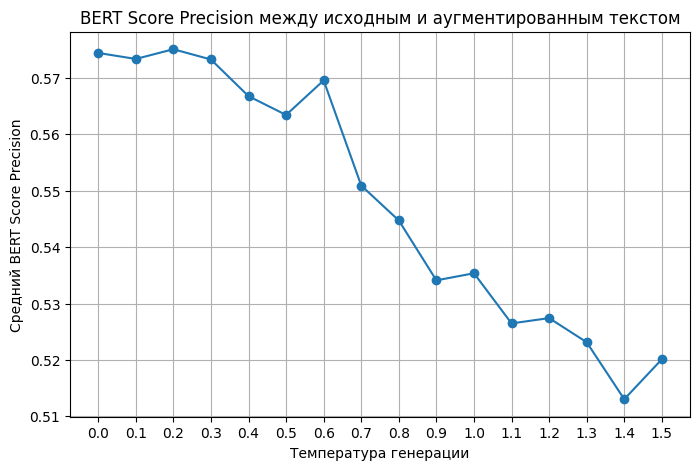

In [25]:
plot_metric(
    results_df_flat,
    "bert_score_precision",
    "BERT Score Precision между исходным и аугментированным текстом",
    "Средний BERT Score Precision"
)

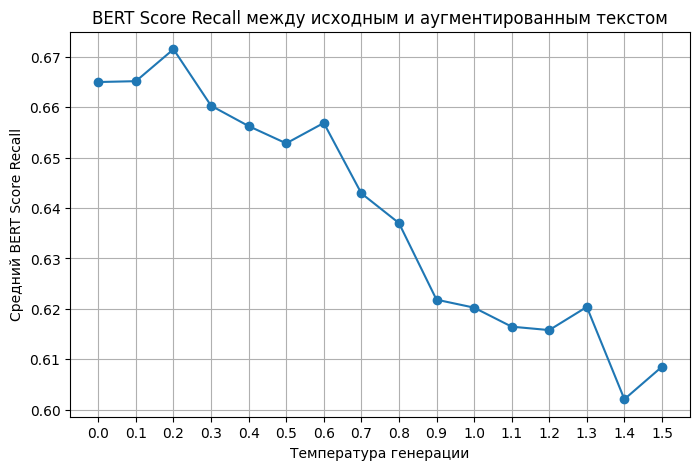

In [26]:
plot_metric(
    results_df_flat,
    "bert_score_recall",
    "BERT Score Recall между исходным и аугментированным текстом",
    "Средний BERT Score Recall"
)

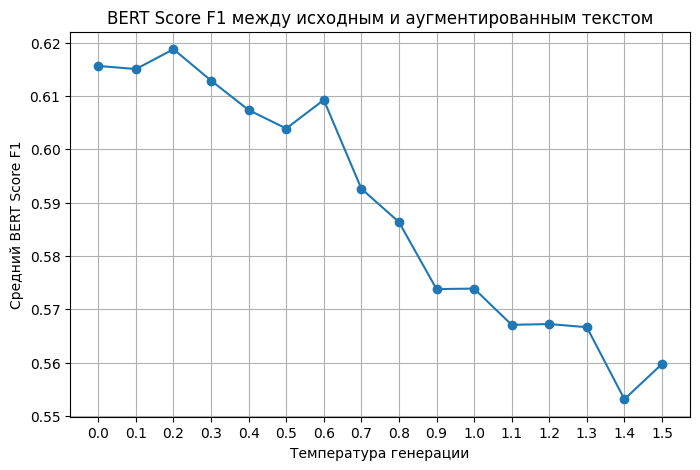

In [27]:
plot_metric(
    results_df_flat,
    "bert_score_f1",
    "BERT Score F1 между исходным и аугментированным текстом",
    "Средний BERT Score F1"
)

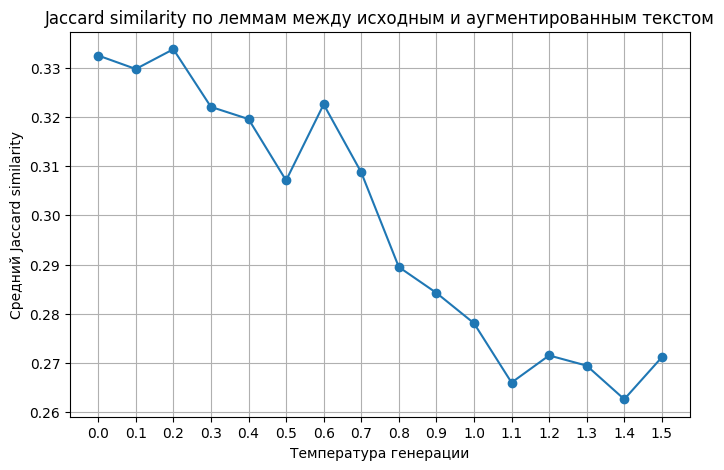

In [28]:
plot_metric(
    results_df_flat,
    "jaccard_lemmas",
    "Jaccard similarity по леммам между исходным и аугментированным текстом",
    "Средний Jaccard similarity"
)

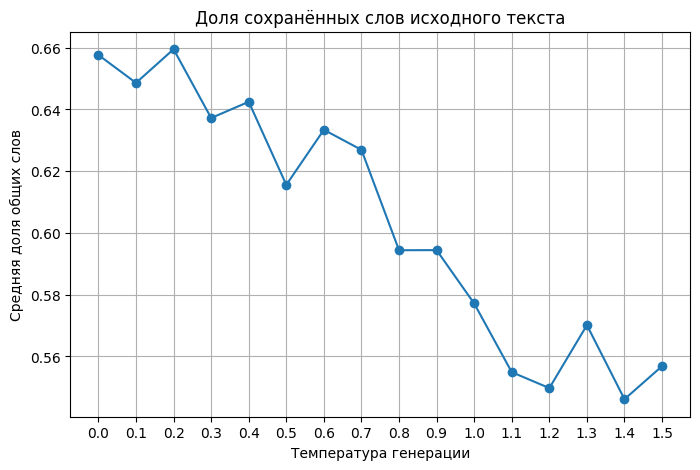

In [29]:
plot_metric(
    results_df_flat,
    "common_words_ratio",
    "Доля сохранённых слов исходного текста",
    "Средняя доля общих слов"
)


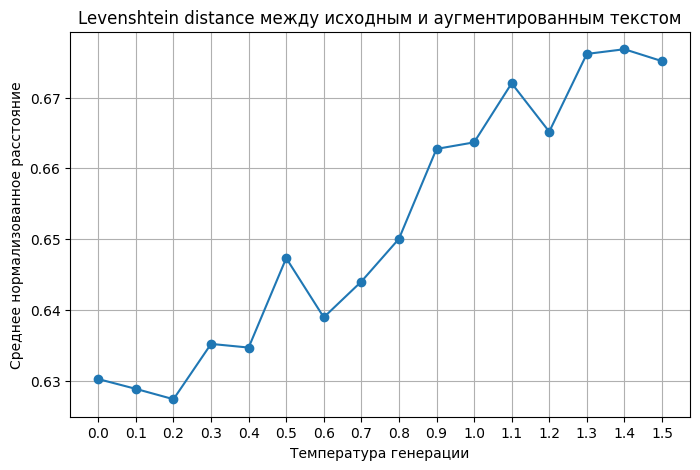

In [30]:
plot_metric(
    results_df_flat,
    "levenshtein_distance",
    "Levenshtein distance между исходным и аугментированным текстом",
    "Среднее нормализованное расстояние"
)

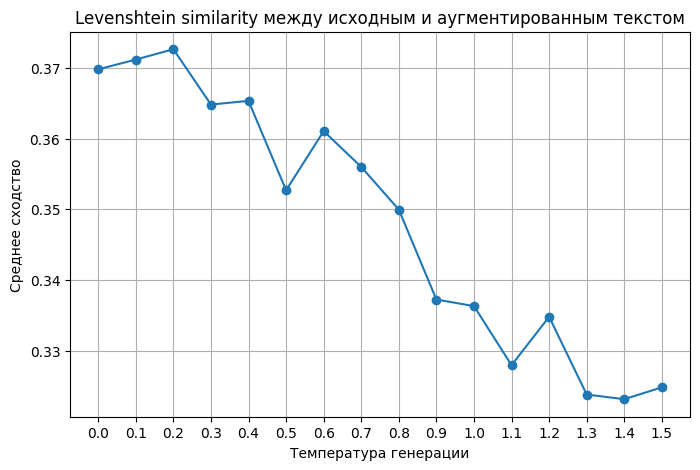

In [31]:
plot_metric(
    results_df_flat,
    "levenshtein_similarity",
    "Levenshtein similarity между исходным и аугментированным текстом",
    "Среднее сходство"
)

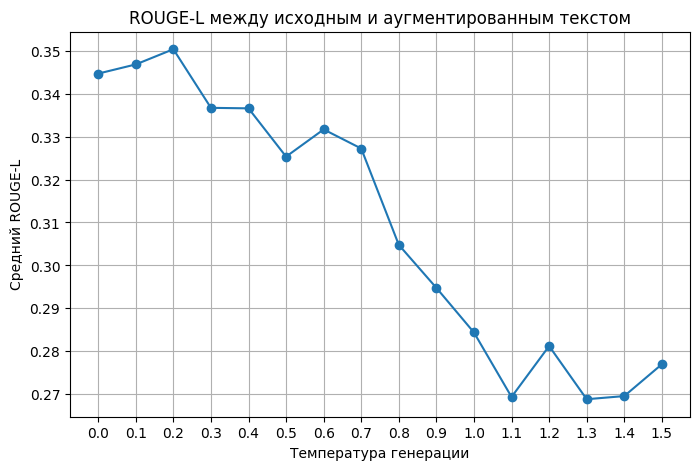

In [32]:
plot_metric(
    results_df_flat,
    "rouge_l",
    "ROUGE-L между исходным и аугментированным текстом",
    "Средний ROUGE-L"
)

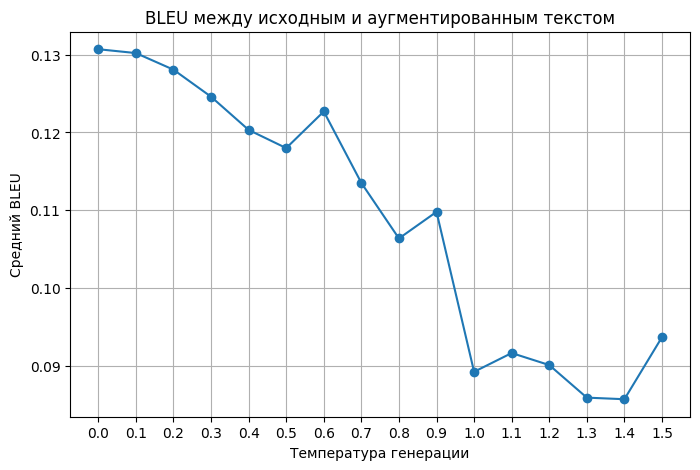

In [33]:
plot_metric(
    results_df_flat,
    "bleu",
    "BLEU между исходным и аугментированным текстом",
    "Средний BLEU"
)

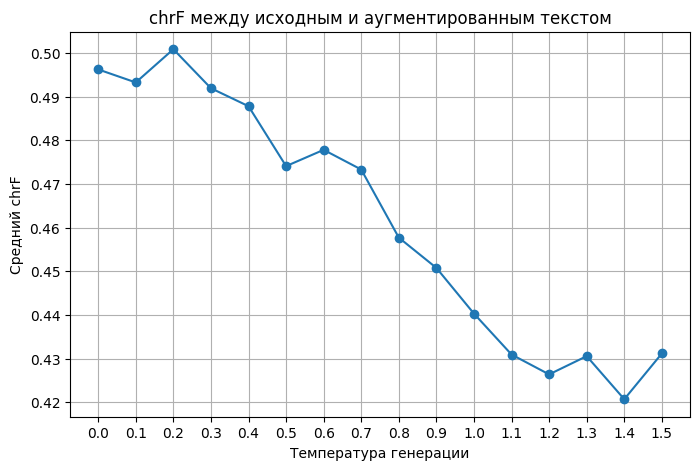

In [34]:
plot_metric(
    results_df_flat,
    "chrf",
    "chrF между исходным и аугментированным текстом",
    "Средний chrF"
)